In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('twitter_human_bots_dataset.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37438 entries, 0 to 37437
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     37438 non-null  int64  
 1   created_at                     37438 non-null  object 
 2   default_profile                37438 non-null  bool   
 3   default_profile_image          37438 non-null  bool   
 4   description                    30181 non-null  object 
 5   favourites_count               37438 non-null  int64  
 6   followers_count                37438 non-null  int64  
 7   friends_count                  37438 non-null  int64  
 8   geo_enabled                    37438 non-null  bool   
 9   id                             37438 non-null  int64  
 10  lang                           29481 non-null  object 
 11  location                       37434 non-null  object 
 12  profile_background_image_url   32939 non-null 

In [ ]:
df.head()

,Unnamed: 0,created_at,default_profile,default_profile_image,description,favourites_count,followers_count,friends_count,geo_enabled,id,...,profile_image_url,screen_name,statuses_count,verified,average_tweets_per_day,account_age_days,account_type,profile_image_path,profile_background_image_path,split
0,0,2009-07-04 22:41:51,False,False,NaN,5007,102,168,False,53779179,...,https://pbs.twimg.com/profile_images/128969130...,paty_castroo,3974,False,0.978,4063,bot,NaN,NaN,0
1,1,2010-01-17 22:54:19,False,False,Television producer. Emmy Award winner. Disney...,1038,60,128,False,105916557,...,https://pbs.twimg.com/profile_images/632916759...,CBirckner,259,False,0.067,3866,human,profile_images/4691ae58668d932bb7e7af22141aecf...,profile_images/4691ae58668d932bb7e7af22141aecf...,0
2,2,2012-03-01 06:05:32,False,False,NaN,2257,599,449,True,509788597,...,https://pbs.twimg.com/profile_images/128853844...,amf_jay,13627,False,4.406,3093,human,NaN,NaN,0
3,3,2009-09-01 04:52:30,False,False,NaN,6407,116,334,True,70601327,...,https://pbs.twimg.com/profile_images/977012905...,SaraCavolo,4432,False,1.107,4005,human,profile_images/d1da9220e4aa376dff03b6f12765171...,profile_images/d1da9220e4aa376dff03b6f12765171...,0
4,4,2010-01-27 17:17:23,False,False,Productor de Televisión - Embajador de @Tienda...,20866,74448,18,True,108999927,...,https://pbs.twimg.com/profile_images/668449819...,DavidHenaoModel,15870,True,4.116,3856,human,profile_images/c65bf625b066ef5f29e14cfcf1ee91f...,profile_images/c65bf625b066ef5f29e14cfcf1ee91f...,0


In [ ]:
print(df['account_type'].value_counts())

account_type
human    25013
bot      12425
Name: count, dtype: int64


In [ ]:
#labele su bot i human, prebacicu ih u numericke bot==1 human == 0
df['label'] = (df['account_type'] == 'bot').astype(int)
df.head()

,Unnamed: 0,created_at,default_profile,default_profile_image,description,favourites_count,followers_count,friends_count,geo_enabled,id,...,screen_name,statuses_count,verified,average_tweets_per_day,account_age_days,account_type,profile_image_path,profile_background_image_path,split,label
0,0,2009-07-04 22:41:51,False,False,NaN,5007,102,168,False,53779179,...,paty_castroo,3974,False,0.978,4063,bot,NaN,NaN,0,1
1,1,2010-01-17 22:54:19,False,False,Television producer. Emmy Award winner. Disney...,1038,60,128,False,105916557,...,CBirckner,259,False,0.067,3866,human,profile_images/4691ae58668d932bb7e7af22141aecf...,profile_images/4691ae58668d932bb7e7af22141aecf...,0,0
2,2,2012-03-01 06:05:32,False,False,NaN,2257,599,449,True,509788597,...,amf_jay,13627,False,4.406,3093,human,NaN,NaN,0,0
3,3,2009-09-01 04:52:30,False,False,NaN,6407,116,334,True,70601327,...,SaraCavolo,4432,False,1.107,4005,human,profile_images/d1da9220e4aa376dff03b6f12765171...,profile_images/d1da9220e4aa376dff03b6f12765171...,0,0
4,4,2010-01-27 17:17:23,False,False,Productor de Televisión - Embajador de @Tienda...,20866,74448,18,True,108999927,...,DavidHenaoModel,15870,True,4.116,3856,human,profile_images/c65bf625b066ef5f29e14cfcf1ee91f...,profile_images/c65bf625b066ef5f29e14cfcf1ee91f...,0,0


In [ ]:
#Feature engineering
#Dodajem feature za opis profila
#I uzimam one koji vec postoje u datasetu
df['description_length'] = df['description'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
df['has_description'] = df['description'].apply(lambda x: 0 if pd.isna(x) or str(x).strip() == '' else 1 )
df['has_location'] = df['location'].apply(lambda x: 0 if pd.isna(x) or str(x).strip().lower() in ['', 'unknown'] else 1)

features = [
    'followers_count',
    'friends_count',
    'favourites_count',
    'statuses_count',
    'average_tweets_per_day',
    'account_age_days',
    'description_length',
    'has_description',
    'has_location',
]

In [ ]:
X = df[features].copy() #ulazni podaci ce biti moji feature-i koje sam izvukla iz dataseta, da se poklapaju sa onim koji cu koristiti posle za predikciju
y = df['label'].copy() #izlazna klasa da li je bot ili human

X = X.fillna(0) #svi ulazni podaci ce biti brojevi, NaN pretvara u 0

print(X.shape)
print(X.head())

(37438, 9)
   followers_count  friends_count  favourites_count  statuses_count  \
0              102            168              5007            3974   
1               60            128              1038             259   
2              599            449              2257           13627   
3              116            334              6407            4432   
4            74448             18             20866           15870   

   average_tweets_per_day  account_age_days  description_length  \
0                   0.978              4063                   0   
1                   0.067              3866                  86   
2                   4.406              3093                   0   
3                   1.107              4005                   0   
4                   4.116              3856                 140   

   has_description  has_location  
0                0             1  
1                1             1  
2                0             0  
3                0 

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) #podela u trenin i test skup podataka
#trening 80% test 20%
#uvek ista podela podataka
#odnos klasa da u trening delu i test delu bude isti, 67% 25013/37438 human i 33% bot 12425/37438

#Standardizacija ulaznih podataka, svi brojevi se svedu na srednju vrednost 0 i standardnu devijaciju 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) #fit transform uzme podatke, nadje mean i std i onda transformise
X_test_scaled  = scaler.transform(X_test) #transform uzme vec izracunate parametre mean i std i po tome transformise
print(f'Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}')

Train: (29950, 9), Test: (7488, 9)


In [ ]:
#SMOTE tehnika koja generise nove primere manjiske klase. kod mene BOT klasa
#radi se samo na trening skupu, kako bi model ispravno naucio, u stvarnom svetu moramo ostaviti isti odnos klasa kako je u stvarnom datasetu

from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_scaled, y_train)
#fit gleda koliko ima predstavnika koje klase i zakljucuje da je BOT manjinska klasa znaci za nju ce generisati
#resample dodaje nove profile
#rezultat su novi nizovi

print('Pre SMOTE: ', y_train.value_counts().to_dict())
print('Posle SMOTE:', pd.Series(y_train_resampled).value_counts().to_dict())

Pre SMOTE:  {0: 20010, 1: 9940}
Posle SMOTE: {0: 20010, 1: 20010}


In [ ]:
print(type(y_train_resampled))

<class 'pandas.core.series.Series'>


In [ ]:
#Definisanje modela feetforward neuronske mreze u PyTorchu
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

#PyTorch vidi samo 1 tip podatka tenzor. Skalar 0d tenzor, Niz 1d tenzor, Matrica 2d tenzor i onda Tenzor == visedimenzionalna matrica
#Koristi tenzore jer se prate vrednosti za backpropagation
#Skalar 42
#Niz [1,2]
#Matrica [[1,2], [3,4]]
#Tenzor [[[1,2], [3,4]], [[5,6], [7,8]]]

#Moj X_train_scaler je matrica [[features*9 profil 1], [features*9 profil 2...]]
X_train_t = torch.tensor(X_train_resampled, dtype = torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype = torch.float32)

#y_train je pandas Series tip, kao niz koji ima indekse 0 1 2 3...
#da bi dobili samo niz, kao 1d tenzor prvo cemo napraviti od y_train npArray sa values
#unsqueeze daje drugu dimenziju kako bih imala 1 kolonu u vise redova
y_train_t = torch.tensor(y_train_resampled.values, dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.float32).unsqueeze(1)


In [ ]:
#TensorDataset i DataLoader

#TensorDataset spaja X_train i y_train u jedan dataset
#[0] profil 1 i sve njegove karakteristike [0] profil 1 i njegova labela
train_dataset = TensorDataset(X_train_t, y_train_t)

#DataLoader deli novi spojeni dataset u Batch-eve
#Batchevi su podeoci mojih podataka, u 1 epohi mreza ce da vidi sve podatke ali podeljene u delove == 935 dela po 32 profila, posle svakog batcha se gleda greska
#Shuffle = True mesa profile posle svake epohe (1 epoha 32 batcha 1 redosled) (2 epoha 32 batcha ali drugaciji redosled Mika=[0] Mika=[1] )
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [ ]:
#Definisanje modela
#PyTorch koristi nn.Module koji govori BotDetection klasa ce biti neuronska mreza

class BotDetection(nn.Module):
  #metoda: self je kao this
  def __init__(self, input_dim):
    #konstruktor koji se poziva kada se pozove metoda, inicijalizuje nn.Module i BotDetection klasa postaje neuronska mreza
    super().__init__()
    #definisemo arhitekturu modela i cuvamo je kao objekat
    self.net = nn.Sequential(
        #linearna funkcija sa ulaznom dimenzijom (9 zbog 9 feature-a po profilu) i izlaznim brojem neurona
        nn.Linear(input_dim, 64),
        #posle svakog linear sloja ide aktivaciona fja da unese nelinearnost modelu
        nn.ReLU(),
        #nasumicno gasenje 30% neurona kako ne bi doslo do overfittinga
        nn.Dropout(0.3),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.Linear(16, 1),
        #poslednji sloj, primenjujemo funkciju koja dobijeni broj pretvara u verovatnocu 0-1, binarna klasifikacija == sigmoid
        nn.Sigmoid()
    )

  #metoda koja se kaze sta se desava kada podaci prodju kroz mrezu
  #x je jedan batch 32 profila i 9 featurea za svakog npr X_batch
  #ona vraca tu verovatnocu
  def forward(self, x):
    return self.net(x)

model = BotDetection(input_dim=X_train_scaled.shape[1]) #[1] posto je X_train_scaled 2d broj kolona su feature-i, nama to treba
#treba nam samo broj 9, nismo uzeli nikakve podatke
#zato nam ne treba sad tenzor koji smo definisali
print(model) #ispis arhitekture



BotDetection(
  (net): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=1, bias=True)
    (9): Sigmoid()
  )
)


početak epohe
      ↓
zero_grad()          ← resetuj gradijente
      ↓
forward pass         ← pošalji batch kroz mrežu
      ↓
loss                 ← izračunaj grešku
      ↓
backward()           ← izračunaj kako poboljšati težine
      ↓
optimizer.step()     ← ažuriraj težine
      ↓
ponovi za sledeći batch (935 puta ukupno)
      ↓
kraj epohe → štampaj prosečan loss
      ↓
ponovi 50 puta

In [ ]:

optimizer = torch.optim.Adam(model.parameters(), lr = 0.001) #definisem koji cu algoritam za optimizovanje tezina da korisnim - Adam bolji je od gradient descent jer pamti prethodne gradijente
criterion = nn.BCELoss() #definisemo loss funkciju
epochs = 50
for epoch in range(epochs): # da prodje kroz svih 50 epoha
  model.train() #model stavljamo u mod treniranja, upali se Dropout
  total_loss = 0 #brojac koji sabira sve greske svih bathceva u 1 epohi, na pocetnu svake epohe je 0

  for X_batch, y_batch in train_loader: #X_batch shape: (32, 9)  ← 32 profila, 9 feature-a   #y_batch shape: (32, 1)  ← 32 tačnih labela
    optimizer.zero_grad() #resetovanje gradijenata na 0 pre svakog batcha
    y_pred = model(X_batch) #kroz model salje batch i dobija predikciju
    loss = criterion(y_pred, y_batch)  #izracunava gresku
    loss.backward() #racuna GRADIJENT na osnovu greske od pozadi backpropagation algoritam
    optimizer.step() #primenjuje taj GRADIJENT i menja tezinu
    total_loss = total_loss + loss.item()
  if (epoch + 1) % 10 == 0:
    print(f'Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}')


Epoch 10/50 | Loss: 0.4661
Epoch 20/50 | Loss: 0.4493
Epoch 30/50 | Loss: 0.4382
Epoch 40/50 | Loss: 0.4330
Epoch 50/50 | Loss: 0.4293


              precision    recall  f1-score   support

       Human       0.90      0.80      0.85      5003
         Bot       0.67      0.81      0.73      2485

    accuracy                           0.80      7488
   macro avg       0.78      0.81      0.79      7488
weighted avg       0.82      0.80      0.81      7488

AUC-ROC: 0.8836459090340563


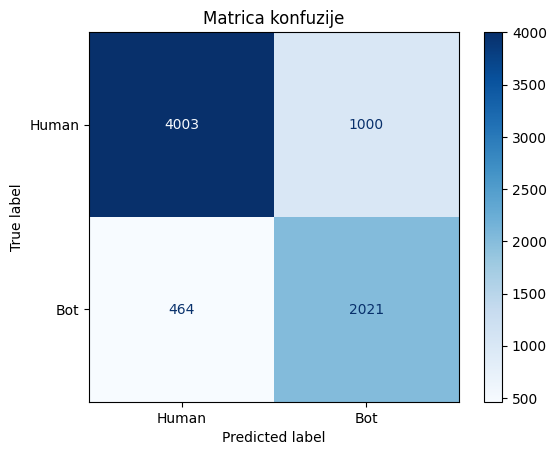

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    y_pred_prob = model(X_test_t).squeeze().numpy()

y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['Human', 'Bot']))
print('AUC-ROC:', roc_auc_score(y_test, y_pred_prob))



# Matrica konfuzije
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Human', 'Bot'])
disp.plot(cmap='Blues')
plt.title('Matrica konfuzije')
plt.show()

In [ ]:
import pandas as pd
import torch
import joblib


pred_df = pd.read_csv('Tweeter_Data_IN.csv')

# Cvorovi iz jezgra novog dataseta
jezgro = {'JayNarwade', 'inaWay_', 'jashwantjazz', 'SANTHOSHAH3', 'PranavJayade',
           'prakalpa', 'DrIndian2', 'derekkandur', 'Atullal71', 'MdAleemshariff',
           'nsvirk', 'psk_eng', 'DrKumarSudhir', 'Satishrathod100', 'MUKESHR23927216',
           'mohitsaxena707', 'rakesh_jsl', 'niraj_t23', 'akjalanca', 'ITC_SaurabhP',
           'ssunyyyyyyyy', 'BhorkarNilesh', 'MayankM50873152', 'JivanPachpute',
           'BidishaSaha12', 'SakalMediaNews', 'SachinSNPandey', 'aneeshmuthyala',
           'nisargshah1489', 'sbtripathiadvoc', 'j123456789u', 'Rudra_82',
           'Rakeshs81787739', 'TaruniGandhi', 'rameshagarwal2', 'NANIPV',
           'drpankajkanwar', 'Gaura2000', 'DeepakK96530224', 'iVishwalok',
           'urdinesh', 'OmiAli5', '486Sanjay', 'minupuri_r', 'analvenerable',
           'BhattShaunak07', 'casteofcreators', 'Abhijit_biyani', 'Sumityadv4u',
           'sumiitksahani', 'AVNISHVASHISITA', 'deepak_mragwani', 'owaizafifa',
           'RoyNabojit', 'Sandeep698Yadav', 'drpreetiyadav9', 'chawla_paras',
           'Raviravirai', 'HemantPratap22', 'AJAYSHARMA1139', '10djfjj',
           'RomasaShukla', 'SrChandanMishra', 'swabhimansonu', 'rajtakke',
           'officialvish007', 'anildamani', 'riteshkarkera', 'SaurabhVShukla',
           'hope_india2014', 'theshubhamgour', 'SidharthaBajpai', 'ImRahulVyas1973',
           'AshBiswal', 'PPMishra18', 'KiranKumarKar3', 'sak8kumar', 'TanurajT',
           'breakruless', 'vidhibharatipar', 'gelesh_ramani', 'modassar43',
           'rajivgoyal', 'riteshgarg1061', 'MKC1_Reddy', 'MrshyamSinghan1',
           'SUBHASH60348539', 'budha1008', 'abhi795', 'sudipta9671287',
           'iamanilshetty', 'Prabhu4BJP', 'DibasKumarSahu', 'Dubeymkd1944',
           'thepiyussh', 'ankitrstg', 'MukundRanjan15', 'Santosh85719350',
           'BokadiyaShubham', 'Sanjays81301051', 'ssr99', 'Santosh88103354',
           'RajanKumarSri17', 'SADEVANTRM', 'bcbehere', 'aumnamah_',
           'tejasvi_ramesh', 'AshishaRajput', 'iamrajeevjha', 'Adv_RakeshSingh',
           'MrRaviRanjan05', 'Nitjan6', 'Amit_RedDevil', 'Nikhil4unik',
           'abhi_krishnatre', 'RAWSindia', 'Dharmin_Soni', 'Shivammsrshanta',
           'SanjuMishra731', 'manjunath_rbg', 'AJAYYAD84048995', 'bhoyarvishal5',
           'ravikant55', 'krispin1991', 'shobhit_05', 'UdageAmol', 'Rajpoot00Lokesh',
           'pkroy0077', 'PRADEIDO', 'MLMANDOWARA', 'Ashu_k_singh', 'chirag_686',
           'kmbhupender', 'akashtiwari9621', 'NamoAmitShukla', 'ArunabhHazarik1',
           'deldanladakhi', 'i_mangeshmhatre', '3783dinesh', 'KamleshbhaiPa10',
           'Ydjain123', 'SatyanarayanT17', 'srstavdheeraj', 'thanecitizens',
           'KARTHIC_VINOBA', 'NareshS69287229', 'DhanalaxmiKarn1', 'RajAsrondkar',
           'AjayGupta6774', 'PJJaiHind', 'Sandy0157385026', 'nik27896',
           'knmishra123', 'itskushalroy', 'rathirathi2001', 'balasubra9',
           'Rohtak_Kohinoor', 'manialmal', 'only_gurubhai', 'raomeenakshi7',
           'ayush_kacholiya', 'AMARNATHJHA', 'shobhitgupta528', 'bahl88',
           'sauravabc16', 'dhruvvvv7', 'heeraman98', 'iNikssoni', 'SibasisSatpathy',
           'mobile_dot', 'prabhat_neeraj', 'abhishek44spl', 'harshpatilp',
           'RajuMon43855976', 'ranjanas89', 'IndianMaverick', 'director_mohanr',
           'VKMishra2171984', 'PranabCBJP', 'sachinattri', 'Amaresh03335514',
           'm37256893', 'GreatScorpion1', 'harendrang8', 'HarshDaTaurian',
           'advocatesarin', 'AjayYadav2119', 'azhar046', 'meraki_says', 'mahi51142874',
           'amitabhnews18', 'jansevakind', 'advocatemj1', 'PraveenPratapS1',
           'varoonagrawal', 'RaghuDeva', 'Ranjeetgupta08', 'bhardwajdeepti3',
           'neercof', 'sonu_shah93', 'AtulGup17260129', 'PREMKUM14299724',
           'karthikdurai_t', 'abhi_singh2244', 'raj2jas', 'BhatiaonGround0',
           'agrawal_sugandh', 'AsifAli75497018', 'TEJASVPANCHAL1', 'ChittorArtFest',
           'TahaAnsari03', 'raj405789sd', 'rao_lk', 'DheerajSingh899', 'vinaygoyal65',
           'jaysureshnaidu', 'rdamodare', 'ksbjpchennai', 'rahul13roc',
           'BhavaneshBehere', 'KirenRijiju', 'agp_98', 'MonuJhumpa', 'KrArvi1',
           'Abhinav8341', 'chandanprajaptk', 'bgsubhash', 'sunita1210', 'VijayJollyBJP',
           'shabirhussain82', 'chhachhiyank', 'Samkt53', 'smdrao', 'raj0687',
           'pathaksamir', 'SushilMohanty1', 'idnani_nandini', 'Ganeshsahoo007',
           'AnilKhatana1990', 'apnathought', 'MIstiyaque', 'DineshS95469482',
           'shekh1959', 'amitmalpani75', 'VinayTiwariVT', 'MirpagarPrakash',
           'iamsinghprakash', 'priteshlhariya', 'SadhuStella', 'IamShoumikDas',
           'nitinshankar', 'rajkumar_1804', 'Shoshit_Banker', 'ashishbiltharia',
           'Kavita_M57', 'RohitYa75249166', 'Anuradha_Singh1', 'MdMdaun0007',
           'sufi_centre', 'alex_gaga1961', 'rupeshpreneur', 'RaghavJhaji',
           'drpatel2111', 'Fight_For_India', 'bRaHmASuJoK', 'RameshKumarKej4',
           'pareekindia', 'VirendraChowdh2', 'navaidhamid', 'nrshimla',
           'Yogi_Akhilesh_', 'pdkamath', 'SunilMalaji', 'natulbj2b', 'Himanshupati1',
           'CA_HEMANTRATHI', 'sailesh2000', 'er_harshbhavsar', 'Saurabh_Munger',
           'HKakriya', 'GroverGuneet', 'ChaurasiaSoumya', 'tejaswinimanogn',
           'Mohanch74268719', 'NationalistIn14', 'ashishsonde', 'AnuragKirti1',
           'Sudhi2803', 'Rkmalhotra12', 'KookeelD', 'pitambarp7', 'mishr_pramod',
           'colkt', 'KavendraSagar', 'kumarpramod815', 'ImkumarGulshan',
           'prabhakarhindu2', 'utsavmethi', 'zasambhu', 'manjur_khann', 'abhilash19_6',
           'kunjbihari1x', 'Divesh3786', 'ajay_kumar_i', 'amarkantca', 'sachin_singla',
           'VGtweets_', 'sunair10', 'rajeshbaniya', 'AshokPr08470555', 'ap_82',
           'mahajan1bhushan', 'gopalkagarwal', 'raghavendra16', 'AdityaT26742572',
           'JawaharLalMeh13', 'KotaNeelima', 'RajatKumarTiwa7', 'sudheerakki175',
           'ArvindB13274904', 'mohta_yash', 'Uttishta_Bharat', 'parveezjaleel',
           'spaceRupesh', 'VijayKapur17', 'sadahaqchief', 'sram_ji', 'sanjoodhariwal',
           'aamirk9892', 'VinodGi62575507', 'Sweety_kumari11', 'AmitAna56825393',
           'AshishS33851324', 'gunshot_rohit', 'dewangs', 'Sanjayk56382160',
           'sameerakapoor', 'linking_the', 'UmaShan15621203', 'akshrAj46', 'dharmu8194',
           'HitendraVora2', 'NarasimhaMyla', 'ashok_dwivedy', 'jainpri2003', 'lotusk3',
           'ravichandransun', 'ashish_s_baghel', 'PrasiddhiF', 'Rajkr5031', 'NashitNr',
           'apnaworldwide', 'imvijay_author', 'DR_DINESH_GUPTA', 'HemendraDr',
           'KumarSahitya2', 'Imgauravgupta_', 'aupadhyay16', 'Arunbha56270931',
           'AliKaashifKhan', 'AjaySha99657793', 'AjayVal87199332', 'anant1anand',
           'immiiAsh', 'patelravi127', 'ilesh_999', 'BinodmauryaG', 'Dishank_09',
           'ShubhankarKuma7', 'AR_RAVIKANT', 'TenNewsDotIn', 'hemalmodiusa',
           'Maddy88372127', 'anand_veecee', 'aripho', '3tarungupta', 'NamahaBharata',
           'kapilambaliya', 'Sam28763059', 'Dev58554643', 'DipenSadrani',
           'Krishna35901251', 'anandpgtkvs', 'NareshSaur', 'IamBunty_Shaikh',
           'realshwetaM', 'ronniesulli147', 'aniruddha_tiger', 'aksingh029',
           'ManishG80580092', 'subhashsagthiya', 'ramraje_shinde', 'RamRajendraMan1',
           'DrSWKorpeINC', 'BaagRafiuddin', 'drnitinchaube', 'MansoorKhanINC',
           'kartikey__singh', 'RakeshA12572734', 'begrajsharma', 'rj_varshaa',
           'Raghuvirsinh54', 'Rathore_Manani', 'sportsdoc4you', 'RathanRameshRR1',
           'gangodichandra', 'ImAnkitRajendra', 'jayashishpandey', 'MSAalamOfficial',
           'manoj_sdm', 'Helping36560414', 'VijendraBathija', 'HemrajUj', 'VipinKu_',
           'SinghSatyjeet', 'SMaharana89', '8527115900', 'bhardwajrakesh4',
           'Sandeepyadav04', 'shashank088', 'GULSHAN91538646', 'drreetusharma',
           'bhushan_UWH', 'Khatrihimansh27', 'neodalit', 'DrKapilKakar', 'Filter_work',
           'MeeraSh06468872', 'yashpsehgal', 'rpsinha393', 'SKG1953', 'rajaditya3',
           'im_sam007', 'IndrajitBairwa', 'Pulkit_Talks', 'ParveshSheoran4',
           'NewIndiaOff', 'MilestoneNgo', 'devanghexa', 'pafcoms', 'AmitSarathe01',
           'SudhirK05383417', 'RaviRamp36', 'abv_02', 'sasikp', 'DharmapuriPran1',
           'raghav_rishabh', 'TjayJugJagger', 'drnarayananraja', 'RahulGa46692878',
           'AbhishekTr', 'IMOHANALOK', 'sumantaghosh', 'dr_rajeevsharma',
           'priyagupta999', 'ashishjswl89', 'ersunilsaxena04', 'DATTAMASKARE1',
           'GandhiParthiv', 'ManishBajpaiBjp', 'SubhransuKumar3', 'SwapnilCM',
           'PRATAPB21838216', 'kmarkri', 'sahillateef7', 'sukantamishra',
           'ManumaneeshK', 'aamritanshuaman', 'kulkarnipiyush1', 'CommonM56559063',
           'Pa1Pavanreddy', 'atharvaindia', 'bbbehera52', 'Chepu13', 'varunmishra79',
           'WriterManisha', 'anilsoni2k', 'pranshu_tomar', 'gnkamat', 'CHANDERBHANVER1',
           'FilmDirSunil', 'KaustubhTri', 'kamleshmodi', 'Ravishashtrikum', 'guptab02',
           'GelotMohanlal', 'msakshi030', 'Shalini50251722', 'RajeshSBhadoria',
           'VjJeet', 'Rakeshsaroha19', 'neerajagr1', 'Prakash10149903', 'dc_gyan',
           'Kmr4Prince', 'garkalvijay', 'sezhiyan_m', 'lokesh_singh_', 'gsec_hbti',
           'NikitTandel', 'BhartiSahyog', 'Mayur1795', 'neerajsonu9995', 'kunal_daga',
           'AmitPal49', 'TBChronicle', 'hc_tripathi', 'hansrajmeena000', 'Real_Rohit98',
           'iTheUshabh', 'Chauhan_csk', 'Iamlokesh1510', 'rajfederer', 'SolankiVardaram',
           'VardhanChitresh', 'Kanhaiy32886799', 'nitishnonu4', 'pushp180', 'ossharma12',
           'avisek_c', 'KsnMurt73963068', 'mvapselvam', 'dchoudhary85',
           'baidyanathbhmct', 'BrindabanMukho3', 'Ramakan35236434', 'GGT_PATIL',
           'anishpandey1', 'scrapsona', 'maheshbaria', 'rajatsharmanks', 'gdc_111',
           'misanketmahadik', 'SameerGaikwad', 'KumarMeonly410', 'shri6385',
           'rajkumarmattu', 'AIRTUINDIA', 'tarun_bhuyan', 'GSubramaniam18',
           'abhinavkmishra', 'RohitDa29783574', 'sharvani67', 'harshit15295',
           'HaifIndia', 'PranjanRajmedhi', 'borana_borana', 'harddyharshvc',
           'AkmishraJsr', 'Bubai_12', 'only4insurance', 'pragatik', 'jatinder_vir',
           'shelar', 'manish_wahal', 'reddythirumal_a', 'KunalSarangi', 'CRajiva',
           'Rashmi_R89', 'prabhakar2707', 'Ervikram44Kumar', 'mrVinay_71',
           'badiger_rudresh', 'rohitcool_singh', 'Mmanish_Sspeaks', 'VvekTyagi',
           'pandeyrohit', 'Abhishek1seven', 'imakshaymalviya', 'Chintan51235861',
           'iamsunil44', 'saurabh23392', 'rajaryan12345', 'bhatanil1973',
           'PrabhuD41653306', 'Hardik_Nik', 'drvipin12', 'kabeer1510', 'iabhaypratap',
           'Deepak29_Jain', 'shwetaberry', 'ImRaina', 'daddy_dangi', 'viratpatil__',
           'raahat25236487', 'Arun_Srk24', 'SR_2789', 'Captaindksingh', 'shray4u',
           'priran', 'ashvindonda', 'vipan26garg', 'NaveenS01111630', 'Santosh38764186',
           'Mrsiddhartomar', 'VivekSharma_SNS', 'vivekGhanekar7', 'pradeepkb28',
           'karthik_b87', 'Shivani90923419'}


pred_filtered = pred_df[pred_df['user_screen_name'].isin(jezgro)].copy()
print(f'Ukupno tvitova u jezgru: {pred_filtered.shape[0]}')
print(f'Ukupno korisnika u jezgru: {pred_filtered["user_screen_name"].nunique()}')

# spajanje svih informacija po korisniku
pred_users = pred_filtered.groupby('user_screen_name').agg({
    'user_followers_count':  'first',
    'user_friends_count':    'first',
    'user_favourites_count': 'first',
    'user_statuses_count':   'first',
    'user_description':      'first',
    'user_location':         'first',
}).reset_index()

print(f'Broj korisnika nakon spajanja: {pred_users.shape[0]}')

Ukupno tvitova u jezgru: 3621
Ukupno korisnika u jezgru: 600
Broj korisnika nakon spajanja: 600


In [ ]:
# Feature-i
pred_users['description_length'] = pred_users['user_description'].apply(
    lambda x: len(str(x)) if pd.notna(x) else 0
)
pred_users['has_description'] = pred_users['user_description'].apply(
    lambda x: 0 if pd.isna(x) or str(x).strip() == '' else 1
)
pred_users['has_location'] = pred_users['user_location'].apply(
    lambda x: 0 if pd.isna(x) or str(x).strip().lower() in ['', 'unknown'] else 1
)

# mapiranje naziva kolona
pred_users = pred_users.rename(columns={
    'user_followers_count':  'followers_count',
    'user_friends_count':    'friends_count',
    'user_favourites_count': 'favourites_count',
    'user_statuses_count':   'statuses_count',
})


#Kolone kojih nema u novom datasetu
# account_age_days datum prvog tvita kao pocetak
reference_date = pd.to_datetime('2020-04-14').tz_localize('UTC')

first_tweet = pred_filtered.groupby('user_screen_name')['created_at'].min()
first_tweet = pd.to_datetime(first_tweet, utc=True)

pred_users['account_age_days'] = pred_users['user_screen_name'].map(
    lambda u: (reference_date - first_tweet[u]).days if u in first_tweet else 0
)

# average_tweets_per_day — broj tvitova / broj dana aktivnosti
tweet_counts = pred_filtered.groupby('user_screen_name').size()
pred_users['average_tweets_per_day'] = pred_users['user_screen_name'].map(
    lambda u: tweet_counts.get(u, 0) / max(pred_users.loc[
        pred_users['user_screen_name'] == u, 'account_age_days'
    ].values[0], 1)
)



features = [
    'followers_count',
    'friends_count',
    'favourites_count',
    'statuses_count',
    'average_tweets_per_day',
    'account_age_days',
    'description_length',
    'has_description',
    'has_location',
]

/tmp/ipykernel_3297/1367322131.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  first_tweet = pd.to_datetime(first_tweet, utc=True)


In [ ]:
X_pred = pred_users[features].fillna(0)

# scaler
X_pred_scaled = scaler.transform(X_pred)
X_pred_t      = torch.tensor(X_pred_scaled, dtype=torch.float32)

In [ ]:
# predikcija
model.eval()
with torch.no_grad():
    pred_probs = model(X_pred_t).squeeze().numpy()

pred_users['bot_probability']   = pred_probs
pred_users['predicted_label']   = (pred_probs > 0.5).astype(int)
pred_users['predicted_account'] = pred_users['predicted_label'].map(
    {0: 'human', 1: 'bot'}
)

In [ ]:
# rezultati

print(pred_users['predicted_account'].value_counts())

print('\n 10 najverovatnijih botova')
print(pred_users[['user_screen_name', 'bot_probability', 'predicted_account']]
      .sort_values('bot_probability', ascending=False)
      .head(10).to_string())

print('\n 10 najverovatnijih humana')
print(pred_users[['user_screen_name', 'bot_probability', 'predicted_account']]
      .sort_values('bot_probability', ascending=True)
      .head(10).to_string())

# cuvanje rezultata
pred_users[['user_screen_name', 'bot_probability', 'predicted_account']].to_csv(
    'predictions_jezgro.csv', index=False
)

predicted_account
human    532
bot       68
Name: count, dtype: int64

 10 najverovatnijih botova
    user_screen_name  bot_probability predicted_account
506   raahat25236487         0.975664               bot
266   SushilMohanty1         0.974370               bot
269      TBChronicle         0.967275               bot
315    amitabhnews18         0.959788               bot
368     dchoudhary85         0.950432               bot
283     VijayKapur17         0.929459               bot
179         PRADEIDO         0.903794               bot
481   only4insurance         0.881932               bot
514    rajaryan12345         0.831155               bot
556       sharvani67         0.830003               bot

 10 najverovatnijih humana
    user_screen_name  bot_probability predicted_account
113          ImRaina         0.071139             human
392    gopalkagarwal         0.074699             human
407       iVishwalok         0.074884             human
383    drreetusharma         0.076